# AFD-CNN Evaluation on MobiFall / MobiAct Data — 4 s Model

Applies the **SisFall 4 s peak/random-balanced model** (`model/sisfall_peak4s_random_balanced_model.ckpt`) to the MobiAct dataset.

**Windowing strategy:**
- **Falls** (FOL, FKL, BSC, SDL): dense sliding window (step = 0.25 s) applied **only to the annotated fall-event phase** of each recording (rows where `label == fall_code`), not the pre-fall or lying period.
- **ADLs** (WAL, JOG, JUM, STU, STN, SCH, CHU): non-overlapping **4 s** windows (step = 4 s) across the full recording.

**Preprocessing:**
- MobiFall accelerometer is in m/s²; converted to g (÷ 9.81) before normalization.
- Resampled from 200 Hz → 100 Hz (AFD-CNN training rate).
- Normalized to [0, 255] matching SisFall ADXL345 13-bit encoding: `(g × 256 + 4096) / 8192 × 255`.
- Input layout: **direct 4 s** — 400 samples × 3 axes = **1200 values** (no repeat).

**MobiFall → model class mapping:**

| MobiFall code | Activity | Model class |
|---|---|---|
| FOL, FKL, BSC, SDL | Fall | 0 — Fall |
| WAL | Walking | 2 — Walk |
| JOG | Jogging | 3 — Jog |
| JUM | Jumping | 4 — Jump |
| STU | Stairs up | 5 — Up-stairs |
| STN | Stairs down | 6 — Down-stairs |
| SCH | Stand to sit | 7 — Stand→Sit |
| CHU | Sit to stand | 9 — Sit→Stand |

## 0. Imports

In [41]:
import os
import sys
import importlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.signal import resample_poly
from collections import defaultdict

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC = '/home/ubuntu/git/FD-CNN/src'
if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)
import cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.4


## 1. Constants

In [42]:
ANN_PATH   = 'MobiFall_dataset/Annotated Data'
MODEL_CKPT = 'model/sisfall_peak4s_random_balanced_model.ckpt'

FS_MOBIFALL = 200   # Hz — MobiAct sample rate
FS_CNN      = 100   # Hz — AFD-CNN training rate
WIN_LEN     = 400   # samples at 100 Hz = 4 s  (400 × 3 = 1200 values, no repeat)
FALL_STEP   = 25    # samples at 100 Hz = 0.25 s  (dense scan of short fall event)
ADL_STEP    = 400   # samples at 100 Hz = 4 s     (non-overlapping, matching window size)
BATCH_SIZE  = 512

# Model output classes
CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NAMES = {
    0: 'Fall',
    2: 'Walk',
    3: 'Jog',
    4: 'Jump',
    5: 'Up-stairs',
    6: 'Down-stairs',
    7: 'Stand\u2192Sit',
    9: 'Sit\u2192Stand',
}
CLASS_COLORS = {
    0: '#e84040',
    2: '#4a8fd4',
    3: '#56b56e',
    4: '#e09c30',
    5: '#9b6bd4',
    6: '#d47bb5',
    7: '#888888',
    9: '#aaaaaa',
}

# MobiFall fall codes → model class 0
FALL_CODES = ['FOL', 'FKL', 'BSC', 'SDL']

# MobiFall ADL codes → model class IDs
MOBI_TO_CLASS = {
    'WAL': 2,
    'JOG': 3,
    'JUM': 4,
    'STU': 5,
    'STN': 6,
    'SCH': 7,
    'CHU': 9,
}

FALL_DESCRIPTIONS = {
    'FOL': 'Forward-lying',
    'FKL': 'Front-knees-lying',
    'BSC': 'Back-sitting-chair',
    'SDL': 'Sideward-lying',
}

print('Model:', MODEL_CKPT)
print(f'Window: {WIN_LEN} samples @ {FS_CNN} Hz = {WIN_LEN/FS_CNN:.1f} s  →  {WIN_LEN * 3} values (no repeat)')
print(f'Fall step: {FALL_STEP} samples = {FALL_STEP/FS_CNN:.2f} s')
print(f'ADL  step: {ADL_STEP}  samples = {ADL_STEP/FS_CNN:.2f} s')

Model: model/sisfall_peak4s_random_balanced_model.ckpt
Window: 400 samples @ 100 Hz = 4.0 s  →  1200 values (no repeat)
Fall step: 25 samples = 0.25 s
ADL  step: 400  samples = 4.00 s


## 2. Load AFD-CNN Model

In [43]:
tf.reset_default_graph()
x_ph            = tf.placeholder(tf.float32, [None, 1200], name='input')
logits_op, keep = cnn_module.fall_net(x_ph)
probs_op        = tf.nn.softmax(logits_op)

saver = tf.train.Saver()
sess  = tf.Session()
saver.restore(sess, MODEL_CKPT)

print('Model restored from:', MODEL_CKPT)
print('Output logits shape:', logits_op.shape)

Model restored from: model/sisfall_peak4s_random_balanced_model.ckpt
Output logits shape: (?, 8)


## 3. Preprocessing Helpers

In [44]:
def extract_windows(arr_ms2, win_len, step, fs_in=FS_MOBIFALL, fs_out=FS_CNN):
    """
    Convert, resample, and window a (N, 3) accelerometer array (m/s²).

    Steps
    -----
    1. m/s² → g  (÷ 9.81)
    2. Polyphase resample from fs_in to fs_out
    3. Apply SisFall ADXL345 normalization: (g × 256 + 4096) / 8192 × 255 → [0, 255]
    4. Slide window of size win_len with given step
    5. Each window flattened to (win_len × 3,) = (1200,) — direct layout, no repeat

    Returns
    -------
    np.ndarray of shape (N_windows, 1200), dtype float32, range [0, 255]
    """
    if len(arr_ms2) < 1:
        return np.empty((0, 1200), dtype=np.float32)

    arr_g      = arr_ms2 / 9.81
    arr_resamp = resample_poly(arr_g.astype(np.float32), fs_out, fs_in, axis=0)

    # SisFall ADXL345 normalization: ADXL345 is 13-bit ±16 g → 256 counts/g
    adc      = arr_resamp * 256.0
    arr_norm = np.clip((adc + 4096.0) / 8192.0 * 255.0, 0.0, 255.0).astype(np.float32)

    n = len(arr_norm)
    windows = []
    for off in range(0, n - win_len + 1, step):
        chunk = arr_norm[off: off + win_len]   # (win_len, 3)
        windows.append(chunk.flatten())        # (1200,)  — direct, no repeat

    return np.array(windows, dtype=np.float32) if windows else np.empty((0, 1200), dtype=np.float32)


def extract_peak_window_norm(arr_ms2, win_len=WIN_LEN, fs_in=FS_MOBIFALL, fs_out=FS_CNN):
    """
    Single peak-centred window from a MobiFall accelerometer segment (m/s²).

    Mirrors the strategy used during training (SisFall_train_peak4s_random_balanced):
    1. m/s² → g
    2. Polyphase resample fs_in → fs_out
    3. Find sample with maximum vector magnitude ‖a‖ in the resampled signal
    4. Centre win_len window on that sample, clamped to recording boundaries
    5. Apply SisFall ADXL345 normalization → [0, 255]
    6. Return flattened (win_len × 3,) = (1200,) vector, or None if segment < win_len.
    """
    arr_g      = (arr_ms2 / 9.81).astype(np.float32)
    arr_resamp = resample_poly(arr_g, fs_out, fs_in, axis=0).astype(np.float32)

    n = len(arr_resamp)
    if n < win_len:
        return None

    magnitude = np.linalg.norm(arr_resamp, axis=1)
    peak_idx  = int(np.argmax(magnitude))
    start     = max(0, min(peak_idx - win_len // 2, n - win_len))

    window_g   = arr_resamp[start: start + win_len]                      # (win_len, 3) in g
    adc        = window_g * 256.0
    window_norm = np.clip((adc + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)

    return window_norm.flatten().astype(np.float32)                      # (1200,)

## 4. Extract Windows — Falls (Peak-Centred, One Window per Recording)

For each fall recording, the **fall-event phase** (rows where `label == fall_code`) is isolated, resampled to 100 Hz, and a single 4 s window is centred on the sample with the **maximum vector magnitude ‖a‖** — matching the windowing strategy used during training.

In [45]:
fall_windows_list = []
fall_labels_gt    = []
fall_source_codes = []

for code in FALL_CODES:
    code_dir    = os.path.join(ANN_PATH, code)
    files       = sorted(f for f in os.listdir(code_dir) if f.endswith('.csv'))
    n_wins_code = 0
    n_skip      = 0

    for fname in files:
        df = pd.read_csv(os.path.join(code_dir, fname))

        # Keep only the fall-event rows (exclude pre-fall STD and post-fall LYI)
        fall_rows = df[df['label'] == code]
        if len(fall_rows) == 0:
            n_skip += 1
            continue

        arr = fall_rows[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32)
        win = extract_peak_window_norm(arr)   # single peak-centred 4 s window

        if win is not None:
            fall_windows_list.append(win)
            fall_labels_gt.append(0)
            fall_source_codes.append(code)
            n_wins_code += 1
        else:
            n_skip += 1   # fall-event segment shorter than 4 s after resampling

    skip_note = f'  ({n_skip} skipped — segment too short)' if n_skip else ''
    print(f'{code} ({FALL_DESCRIPTIONS[code]}): {len(files)} files  →  {n_wins_code} peak windows{skip_note}')

fall_windows = (np.vstack(fall_windows_list)
                if fall_windows_list
                else np.empty((0, 1200), dtype=np.float32))
print(f'\nTotal fall windows : {len(fall_windows)}')

FOL (Forward-lying): 192 files  →  1 peak windows  (191 skipped — segment too short)
FKL (Front-knees-lying): 192 files  →  2 peak windows  (190 skipped — segment too short)
BSC (Back-sitting-chair): 191 files  →  7 peak windows  (184 skipped — segment too short)
SDL (Sideward-lying): 192 files  →  0 peak windows  (192 skipped — segment too short)

Total fall windows : 10


## 5. Extract Windows — ADLs (Non-Overlapping 4 s)

In [46]:
adl_windows_list = []
adl_labels_gt    = []
adl_source_codes = []

for code, class_id in MOBI_TO_CLASS.items():
    code_dir = os.path.join(ANN_PATH, code)
    if not os.path.isdir(code_dir):
        print(f'{code}: directory not found, skipping')
        continue

    files       = sorted(f for f in os.listdir(code_dir) if f.endswith('.csv'))
    n_wins_code = 0

    for fname in files:
        df   = pd.read_csv(os.path.join(code_dir, fname))
        arr  = df[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32)
        wins = extract_windows(arr, win_len=WIN_LEN, step=ADL_STEP)

        if len(wins) > 0:
            adl_windows_list.append(wins)
            adl_labels_gt.extend([class_id] * len(wins))
            adl_source_codes.extend([code] * len(wins))
            n_wins_code += len(wins)

    print(f'{code} \u2192 class {class_id} ({CLASS_NAMES[class_id]}): '
          f'{len(files)} files \u2192 {n_wins_code} windows')

adl_windows = np.vstack(adl_windows_list) if adl_windows_list else np.empty((0, 1200), dtype=np.float32)
print(f'\nTotal ADL windows  : {len(adl_windows)}')

WAL → class 2 (Walk): 61 files → 4515 windows
JOG → class 3 (Jog): 183 files → 1281 windows
JUM → class 4 (Jump): 183 files → 1281 windows
STU → class 5 (Up-stairs): 364 files → 727 windows
STN → class 6 (Down-stairs): 365 files → 730 windows
SCH → class 7 (Stand→Sit): 365 files → 365 windows
CHU → class 9 (Sit→Stand): 114 files → 114 windows

Total ADL windows  : 9013


In [47]:
all_windows = np.vstack([fall_windows, adl_windows])
all_gt      = np.array(fall_labels_gt + adl_labels_gt, dtype=np.int32)

print(f'Total windows      : {len(all_windows):,}')
print(f'  Fall             : {len(fall_windows):,}')
print(f'  ADL              : {len(adl_windows):,}')
print(f'Window tensor      : {all_windows.shape}  [{all_windows.min():.1f}, {all_windows.max():.1f}]')
print()
print('Class distribution (ground truth):')
for cls in CLASS_LIST:
    n = (all_gt == cls).sum()
    print(f'  {CLASS_NAMES[cls]:12s} (class {cls}): {n:,}')

Total windows      : 9,023
  Fall             : 10
  ADL              : 9,013
Window tensor      : (9023, 1200)  [111.4, 144.4]

Class distribution (ground truth):
  Fall         (class 0): 10
  Walk         (class 2): 4,515
  Jog          (class 3): 1,281
  Jump         (class 4): 1,281
  Up-stairs    (class 5): 727
  Down-stairs  (class 6): 730
  Stand→Sit    (class 7): 365
  Sit→Stand    (class 9): 114


## 6. Run Inference

In [48]:
all_probs_list  = []
all_logits_list = []

for start in range(0, len(all_windows), BATCH_SIZE):
    batch = all_windows[start: start + BATCH_SIZE]
    logits_b, probs_b = sess.run(
        [logits_op, probs_op],
        feed_dict={x_ph: batch, keep: 1.0},
    )
    all_probs_list.append(probs_b)
    all_logits_list.append(logits_b)

all_probs  = np.vstack(all_probs_list)   # (N, 8)
all_logits = np.vstack(all_logits_list)  # (N, 8)

pred_idx   = np.argmax(all_probs, axis=1)
all_pred   = np.array([CLASS_LIST[i] for i in pred_idx], dtype=np.int32)
fall_idx   = CLASS_LIST.index(0)
fall_probs = all_probs[:, fall_idx]

print(f'Inference complete \u2014 {len(all_windows):,} windows')
print()
print('Predicted class distribution:')
for cls in CLASS_LIST:
    n = (all_pred == cls).sum()
    print(f'  {CLASS_NAMES[cls]:12s}: {n:,}')

Inference complete — 9,023 windows

Predicted class distribution:
  Fall        : 8,114
  Walk        : 350
  Jog         : 270
  Jump        : 9
  Up-stairs   : 86
  Down-stairs : 16
  Stand→Sit   : 7
  Sit→Stand   : 171


## 7. Confusion Matrix

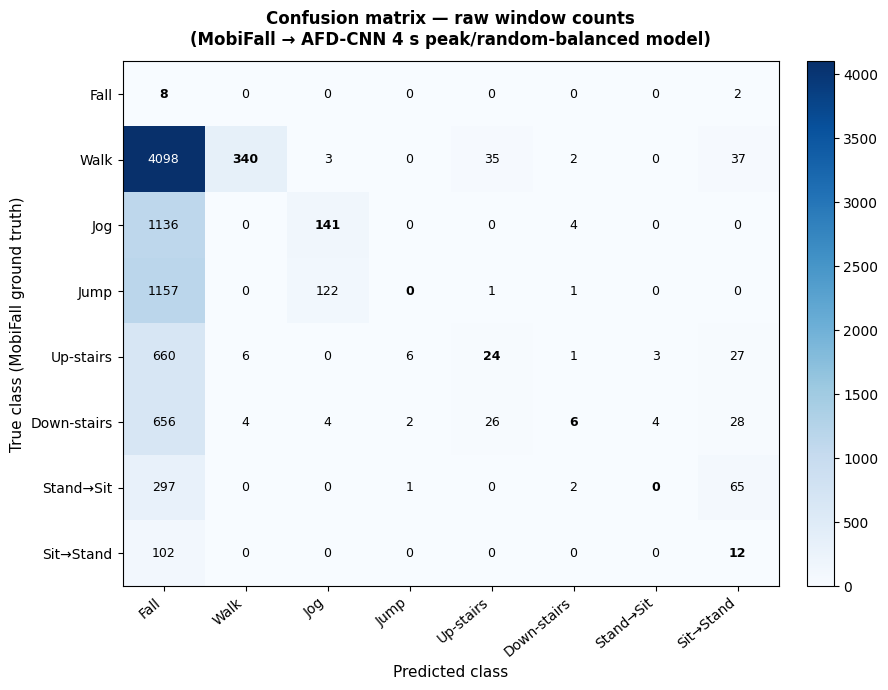

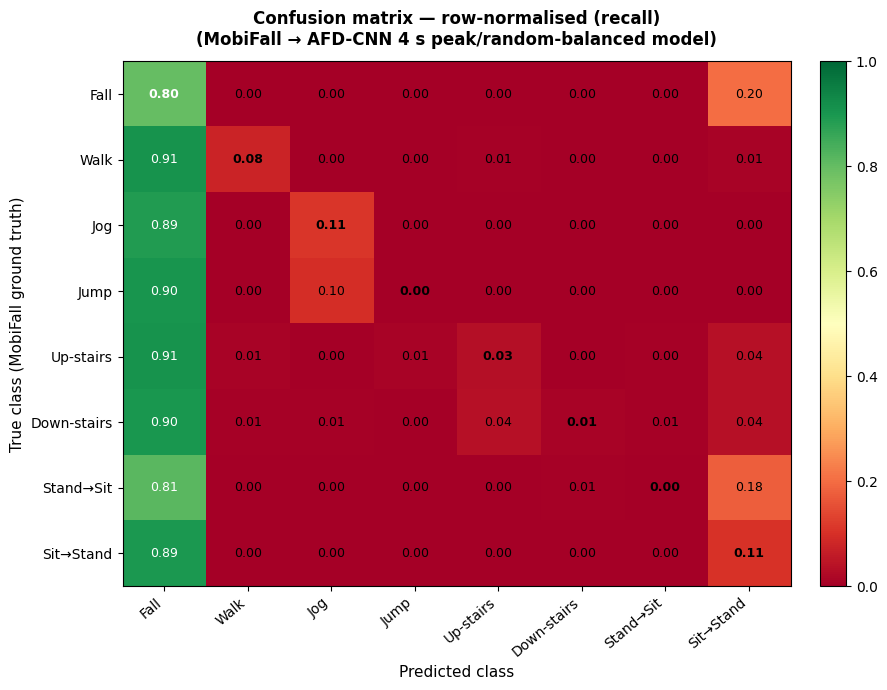

In [49]:
n_classes    = len(CLASS_LIST)
cls_to_idx   = {cls: i for i, cls in enumerate(CLASS_LIST)}
class_labels = [CLASS_NAMES[c] for c in CLASS_LIST]

# Raw count confusion matrix
cm = np.zeros((n_classes, n_classes), dtype=np.int64)
for gt, pr in zip(all_gt, all_pred):
    cm[cls_to_idx[gt], cls_to_idx[pr]] += 1

# Row-normalised (recall) matrix
row_sums  = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_normed = cm / row_sums


def plot_confusion_matrix(matrix, labels, title, fmt, cmap, vmin=None, vmax=None, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, interpolation='nearest', cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Predicted class', fontsize=11)
    ax.set_ylabel('True class (MobiFall ground truth)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    thresh = (matrix.max() + matrix.min()) / 2.0 if vmin is None else (vmin + vmax) / 2.0
    for i in range(len(labels)):
        for j in range(len(labels)):
            val   = matrix[i, j]
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, format(val, fmt), ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold' if i == j else 'normal')

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    cm, class_labels,
    title='Confusion matrix \u2014 raw window counts\n(MobiFall \u2192 AFD-CNN 4 s peak/random-balanced model)',
    fmt='d', cmap='Blues',
)

plot_confusion_matrix(
    cm_normed, class_labels,
    title='Confusion matrix \u2014 row-normalised (recall)\n(MobiFall \u2192 AFD-CNN 4 s peak/random-balanced model)',
    fmt='.2f', cmap='RdYlGn', vmin=0.0, vmax=1.0,
)

## 8. Per-Class Metrics

In [50]:
rows = []
for i, cls in enumerate(CLASS_LIST):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    n_true    = cm[i, :].sum()
    recall    = tp / n_true if n_true > 0 else 0.0
    prec_d    = tp + fp
    precision = tp / prec_d if prec_d > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    spec_d    = fp + tn
    specificity = tn / spec_d if spec_d > 0 else 0.0

    rows.append({
        'Class': CLASS_NAMES[cls],
        'N true': n_true,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Recall (sensitivity)': recall,
        'Precision': precision,
        'F1': f1,
        'Specificity': specificity,
    })

metrics_df = pd.DataFrame(rows)


def _highlight_fall(row):
    color = 'background-color: #922b21; color: white' if row['Class'] == 'Fall' else ''
    return [color] * len(row)


styled = (
    metrics_df.style
    .apply(_highlight_fall, axis=1)
    .format({
        'Recall (sensitivity)': '{:.3f}',
        'Precision': '{:.3f}',
        'F1': '{:.3f}',
        'Specificity': '{:.3f}',
        'N true': '{:,}',
        'TP': '{:,}',
        'FP': '{:,}',
        'FN': '{:,}',
    })
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_caption('Per-class metrics \u2014 AFD-CNN 4 s model on MobiFall')
    .background_gradient(subset=['Recall (sensitivity)', 'F1'], cmap='RdYlGn', vmin=0, vmax=1)
)
display(styled)

,Class,N true,TP,FP,FN,Recall (sensitivity),Precision,F1,Specificity
0,Fall,10,8,"8,106",2,0.800,0.001,0.002,0.101
1,Walk,"4,515",340,10,"4,175",0.075,0.971,0.140,0.998
2,Jog,"1,281",141,129,"1,140",0.110,0.522,0.182,0.983
3,Jump,"1,281",0,9,"1,281",0.000,0.000,0.000,0.999
4,Up-stairs,727,24,62,703,0.033,0.279,0.059,0.993
5,Down-stairs,730,6,10,724,0.008,0.375,0.016,0.999
6,Stand→Sit,365,0,7,365,0.000,0.000,0.000,0.999
7,Sit→Stand,114,12,159,102,0.105,0.070,0.084,0.982


## 9. Fall Detection Summary

In [51]:
# Binary fall-detection summary: Fall (class 0) vs. everything else
is_fall_gt   = (all_gt   == 0)
is_fall_pred = (all_pred == 0)

tp_fall = ( is_fall_gt &  is_fall_pred).sum()
fn_fall = ( is_fall_gt & ~is_fall_pred).sum()
fp_fall = (~is_fall_gt &  is_fall_pred).sum()
tn_fall = (~is_fall_gt & ~is_fall_pred).sum()

sensitivity = tp_fall / (tp_fall + fn_fall)
specificity = tn_fall / (tn_fall + fp_fall)
accuracy    = (tp_fall + tn_fall) / len(all_gt)

print('=== Binary fall detection (Fall vs. all ADLs) ===')
print(f'  True  Positives (fall correctly detected)   : {tp_fall:,}')
print(f'  False Negatives (fall missed)               : {fn_fall:,}')
print(f'  False Positives (ADL flagged as fall)       : {fp_fall:,}')
print(f'  True  Negatives (ADL correctly rejected)    : {tn_fall:,}')
print()
print(f'  Sensitivity (recall for falls) : {sensitivity:.3f}')
print(f'  Specificity (recall for ADLs)  : {specificity:.3f}')
print(f'  Overall accuracy               : {accuracy:.3f}')
print()

# Per fall type
print('--- Recall per fall type ---')
for code in FALL_CODES:
    code_mask   = np.array(fall_source_codes) == code
    pred_code   = all_pred[:len(fall_labels_gt)][code_mask]
    recall_code = (pred_code == 0).mean() if len(pred_code) > 0 else 0.0
    print(f'  {code} ({FALL_DESCRIPTIONS[code]:20s}): '
          f'{(pred_code == 0).sum():3d}/{len(pred_code):3d} windows = {recall_code:.3f}')

=== Binary fall detection (Fall vs. all ADLs) ===
  True  Positives (fall correctly detected)   : 8
  False Negatives (fall missed)               : 2
  False Positives (ADL flagged as fall)       : 8,106
  True  Negatives (ADL correctly rejected)    : 907

  Sensitivity (recall for falls) : 0.800
  Specificity (recall for ADLs)  : 0.101
  Overall accuracy               : 0.101

--- Recall per fall type ---
  FOL (Forward-lying       ):   1/  1 windows = 1.000
  FKL (Front-knees-lying   ):   2/  2 windows = 1.000
  BSC (Back-sitting-chair  ):   5/  7 windows = 0.714
  SDL (Sideward-lying      ):   0/  0 windows = 0.000


## 10. P(Fall) Distributions — Falls vs ADLs

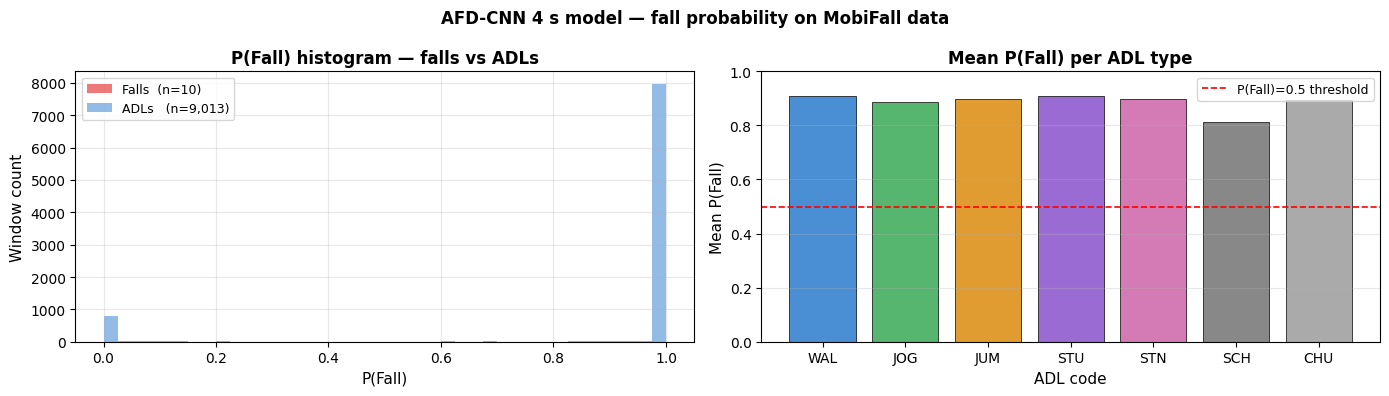

Falls  — mean P(Fall): 0.786  |  median: 0.997
ADLs   — mean P(Fall): 0.898  |  median: 1.000


In [52]:
n_fall_wins  = len(fall_windows)
p_fall_falls = fall_probs[:n_fall_wins]   # P(Fall) for actual falls
p_fall_adls  = fall_probs[n_fall_wins:]   # P(Fall) for ADLs

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Histogram
bins = np.linspace(0, 1, 41)
axes[0].hist(p_fall_falls, bins=bins, color='#e84040', alpha=0.7, label=f'Falls  (n={len(p_fall_falls):,})')
axes[0].hist(p_fall_adls,  bins=bins, color='#4a8fd4', alpha=0.6, label=f'ADLs   (n={len(p_fall_adls):,})')
axes[0].set_xlabel('P(Fall)', fontsize=11)
axes[0].set_ylabel('Window count', fontsize=11)
axes[0].set_title('P(Fall) histogram \u2014 falls vs ADLs', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Per ADL code: mean P(Fall)
adl_code_arr  = np.array(adl_source_codes)
adl_probs_arr = p_fall_adls
codes_ordered = list(MOBI_TO_CLASS.keys())
mean_pfalls   = [adl_probs_arr[adl_code_arr == c].mean() for c in codes_ordered]

bar_colors = [CLASS_COLORS[MOBI_TO_CLASS[c]] for c in codes_ordered]
axes[1].bar(codes_ordered, mean_pfalls, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='P(Fall)=0.5 threshold')
axes[1].set_xlabel('ADL code', fontsize=11)
axes[1].set_ylabel('Mean P(Fall)', fontsize=11)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Mean P(Fall) per ADL type', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('AFD-CNN 4 s model \u2014 fall probability on MobiFall data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Falls  \u2014 mean P(Fall): {p_fall_falls.mean():.3f}  |  median: {np.median(p_fall_falls):.3f}')
print(f'ADLs   \u2014 mean P(Fall): {p_fall_adls.mean():.3f}  |  median: {np.median(p_fall_adls):.3f}')

## 10b. All-Class Logit Distributions — Falls vs ADLs

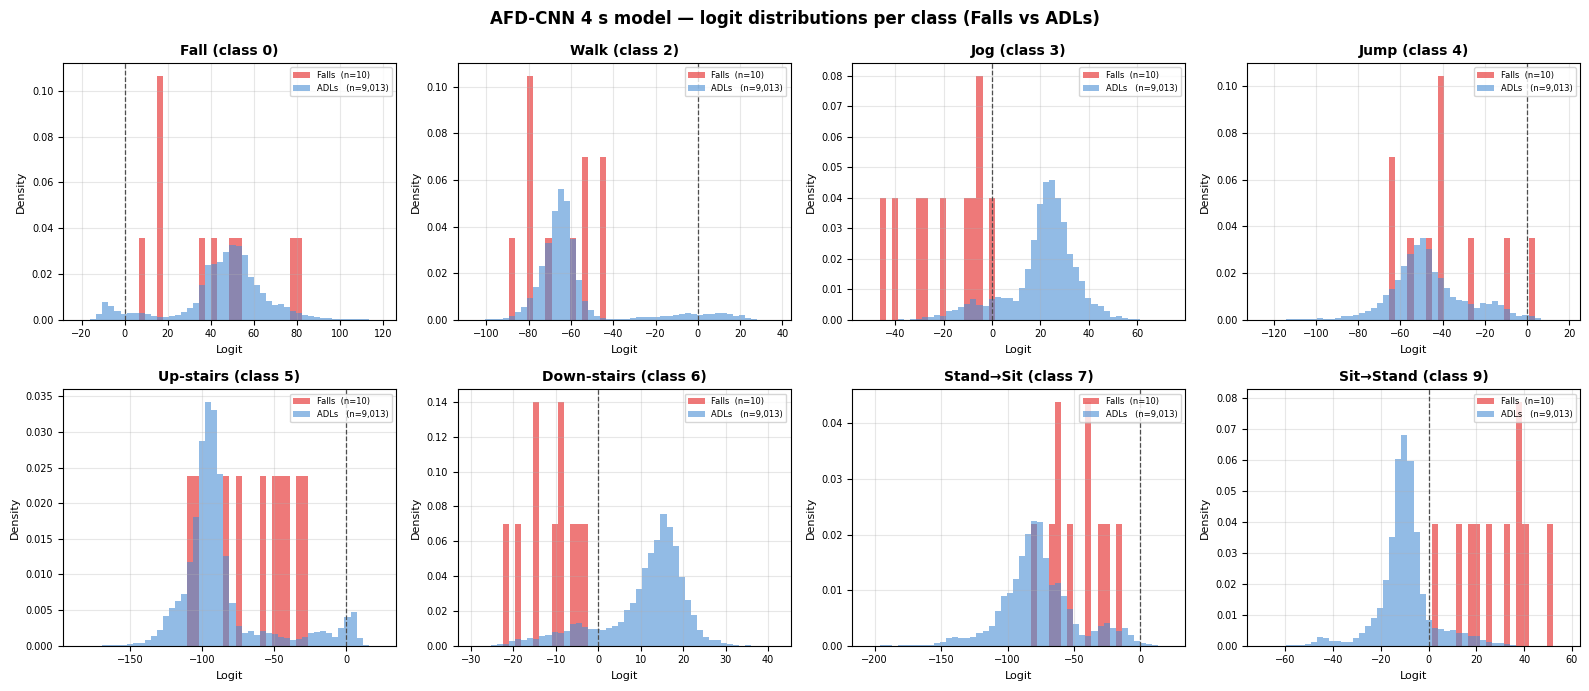

Class            Fall mean    Fall std    ADL mean     ADL std
----------------------------------------------------------
Fall                 39.70       25.06       46.19       20.44
Walk                -65.26       15.23      -58.84       22.07
Jog                 -18.81       15.38       20.77       14.03
Jump                -38.35       20.57      -46.56       17.79
Up-stairs           -62.82       27.84      -86.83       30.69
Down-stairs         -11.25        5.96       10.86        9.93
Stand→Sit           -47.52       19.05      -76.58       27.96
Sit→Stand            28.04       14.15       -9.83       11.22


In [53]:
fall_logits_all = all_logits[:n_fall_wins]   # (n_fall, 8)
adl_logits_all  = all_logits[n_fall_wins:]   # (n_adl, 8)

ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for idx, cls_id in enumerate(CLASS_LIST):
    ax = axes[idx]
    f_vals = fall_logits_all[:, idx]
    a_vals = adl_logits_all[:, idx]

    lo = min(f_vals.min(), a_vals.min())
    hi = max(f_vals.max(), a_vals.max())
    margin = max((hi - lo) * 0.05, 1.0)
    bins = np.linspace(lo - margin, hi + margin, 51)

    ax.hist(f_vals, bins=bins, color='#e84040', alpha=0.7, density=True,
            label=f'Falls  (n={len(f_vals):,})')
    ax.hist(a_vals, bins=bins, color='#4a8fd4', alpha=0.6, density=True,
            label=f'ADLs   (n={len(a_vals):,})')
    ax.axvline(0, color='0.3', linestyle='--', linewidth=0.9)
    ax.set_title(f'{CLASS_NAMES[cls_id]} (class {cls_id})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Logit', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc='upper right')

fig.suptitle('AFD-CNN 4 s model — logit distributions per class (Falls vs ADLs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics per class
print(f'{"Class":<14}  {"Fall mean":>10}  {"Fall std":>10}  {"ADL mean":>10}  {"ADL std":>10}')
print('-' * 58)
for idx, cls_id in enumerate(CLASS_LIST):
    f_vals = fall_logits_all[:, idx]
    a_vals = adl_logits_all[:, idx]
    print(f'{CLASS_NAMES[cls_id]:<14}  {f_vals.mean():>10.2f}  {f_vals.std():>10.2f}'
          f'  {a_vals.mean():>10.2f}  {a_vals.std():>10.2f}')

## 11. Per-Fall-Type Recall Bar Chart

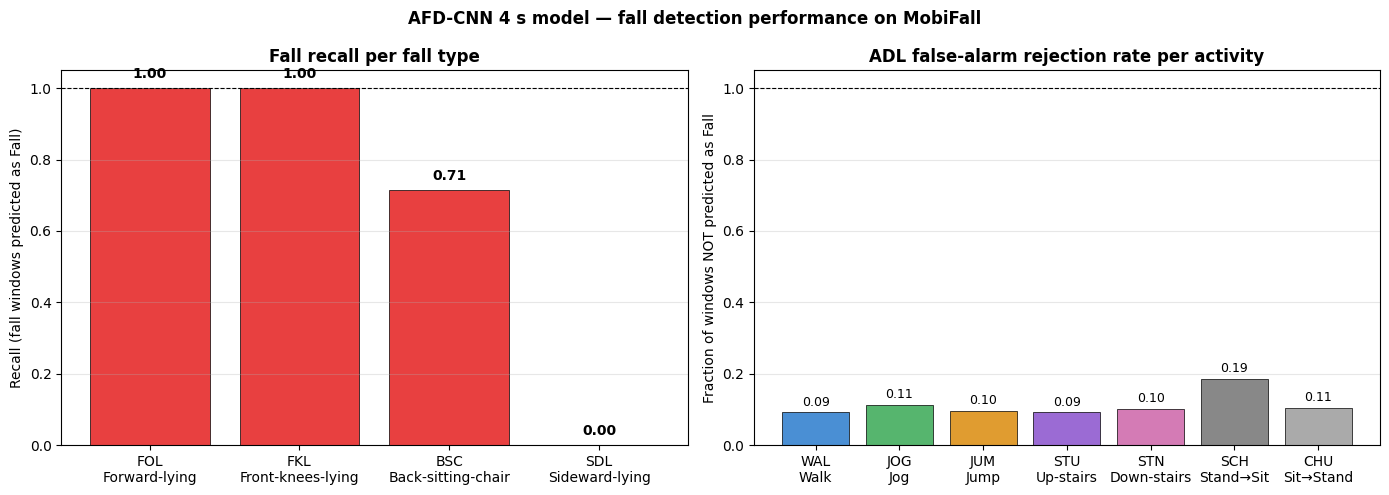

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: recall per fall type
fall_recalls      = []
fall_code_labels  = []
for code in FALL_CODES:
    code_mask = np.array(fall_source_codes) == code
    pred_code = all_pred[:len(fall_labels_gt)][code_mask]
    recall    = (pred_code == 0).mean() if len(pred_code) > 0 else 0.0
    fall_recalls.append(recall)
    fall_code_labels.append(f'{code}\n{FALL_DESCRIPTIONS[code]}')

bar_fall = axes[0].bar(fall_code_labels, fall_recalls, color='#e84040', edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Recall (fall windows predicted as Fall)', fontsize=10)
axes[0].set_title('Fall recall per fall type', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bar_fall, fall_recalls):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: ADL false-alarm rejection rate
adl_specificities = []
adl_labels_plot   = []
for code, class_id in MOBI_TO_CLASS.items():
    code_mask           = np.array(adl_source_codes) == code
    pred_code           = all_pred[len(fall_labels_gt):][code_mask]
    specificity_code    = (pred_code != 0).mean() if len(pred_code) > 0 else 0.0
    adl_specificities.append(specificity_code)
    adl_labels_plot.append(f'{code}\n{CLASS_NAMES[class_id]}')

bar_adl = axes[1].bar(adl_labels_plot, adl_specificities,
                      color=[CLASS_COLORS[MOBI_TO_CLASS[c]] for c in MOBI_TO_CLASS],
                      edgecolor='black', linewidth=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Fraction of windows NOT predicted as Fall', fontsize=10)
axes[1].set_title('ADL false-alarm rejection rate per activity', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bar_adl, adl_specificities):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9)

fig.suptitle('AFD-CNN 4 s model \u2014 fall detection performance on MobiFall', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Most-Confident Example Windows per Predicted Class

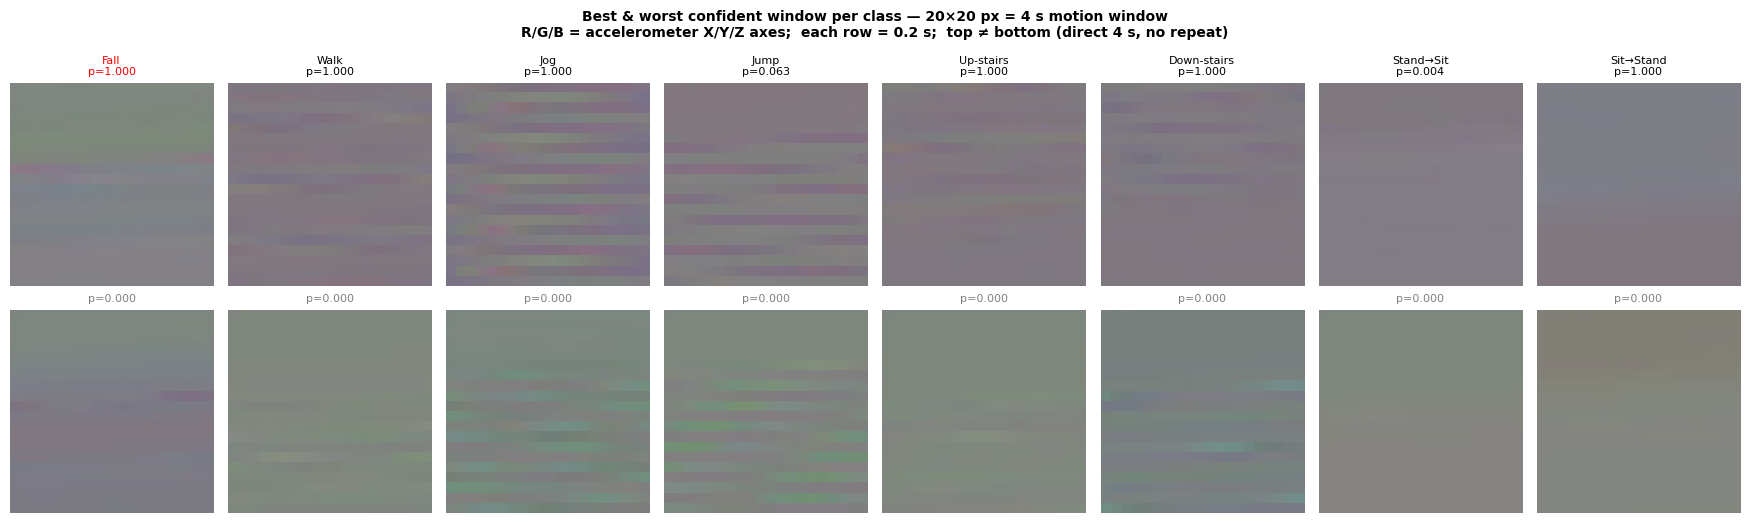

In [55]:
fig, axes = plt.subplots(2, n_classes, figsize=(2.2 * n_classes, 5.5))

for col, cls in enumerate(CLASS_LIST):
    cls_idx = CLASS_LIST.index(cls)

    if cls == 0:  # Fall — pick from fall windows only
        cand_mask = np.arange(len(fall_windows))
        scores    = all_probs[:len(fall_windows), cls_idx]
    else:         # ADL — pick from ADL windows of the matching ground-truth class
        gt_mask   = np.array(adl_labels_gt) == cls
        cand_mask = np.where(gt_mask)[0] + len(fall_windows)
        scores    = all_probs[cand_mask, cls_idx]

    best_local  = int(np.argmax(scores))
    best_global = cand_mask[best_local]
    best_prob   = scores[best_local]

    # Reshape 1200-value vector directly to 20×20×3 (no repeat — top ≠ bottom half)
    img   = all_windows[best_global].reshape(20, 20, 3) / 255.0
    name  = CLASS_NAMES[cls]
    color = 'red' if cls == 0 else 'black'

    axes[0][col].imshow(img)
    axes[0][col].set_title(f'{name}\np={best_prob:.3f}', fontsize=8, color=color)
    axes[0][col].axis('off')

    worst_local  = int(np.argmin(scores))
    worst_global = cand_mask[worst_local]
    worst_prob   = scores[worst_local]
    img2 = all_windows[worst_global].reshape(20, 20, 3) / 255.0

    axes[1][col].imshow(img2)
    axes[1][col].set_title(f'p={worst_prob:.3f}', fontsize=8, color='grey')
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Best (most\nconfident)', fontsize=8, rotation=0, labelpad=50)
axes[1][0].set_ylabel('Worst (least\nconfident)', fontsize=8, rotation=0, labelpad=50)

fig.suptitle(
    'Best & worst confident window per class \u2014 20\u00d720 px = 4 s motion window\n'
    'R/G/B = accelerometer X/Y/Z axes;  each row = 0.2 s;  top \u2260 bottom (direct 4 s, no repeat)',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 13. Hard Decision Rule — Binary Fall / No-Fall (Stand→Sit exempt)

A deterministic rule applied on top of the raw model logits.  
Stand→Sit (class 7) is **exempt** from the "all non-fall logits < 0" condition — instead, only the fall logit must exceed it:

| Condition | Decision |
|---|---|
| `logit_fall > 50` **and** all non-fall logits *(except Stand→Sit)* `< 0` **and** `logit_fall > logit_Stand→Sit` | **Fall** |
| otherwise | **No-fall** |

Rationale: Stand→Sit produces deceleration bursts that can push its logit positive; the model should still flag a fall if it dominates over that class.

Rule: logit_fall > 50  AND  non-fall (excl. Stand→Sit) < 0  AND  fall > Stand→Sit
  TP=0  FN=10  FP=5  TN=9,008
  Sensitivity : 0.0000
  Specificity : 0.9994
  Precision   : 0.0000
  F1          : 0.0000



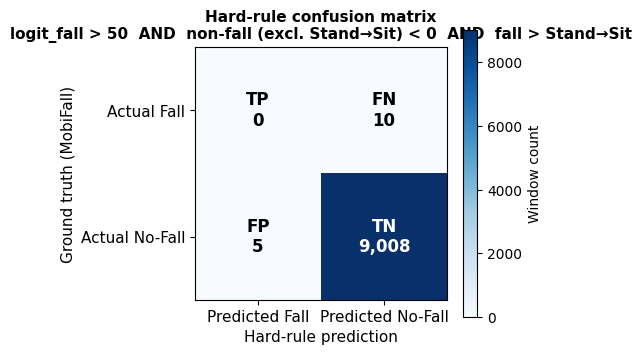

--- Fall recall per fall type ---
  FOL (Forward-lying       ):   0/  1 = 0.000
  FKL (Front-knees-lying   ):   0/  2 = 0.000
  BSC (Back-sitting-chair  ):   0/  7 = 0.000
  SDL (Sideward-lying      ):   0/  0 = 0.000

=== Binary comparison: softmax argmax vs hard rule (Stand→Sit exempt) ===
                                    Sens      Spec      TP      FP      FN
----------------------------------------------------------------------
Softmax argmax                    0.8000    0.1006       8   8,106       2
Hard rule (Stand→Sit exempt)      0.0000    0.9994       0       5      10


In [56]:
FALL_LOGIT_THRESH = 50

FALL_CLS_IDX = CLASS_LIST.index(0)
SCH_IDX      = CLASS_LIST.index(7)   # Stand→Sit (exempt from the < 0 requirement)

# All non-fall columns except Stand→Sit
NONFAL_EXCEPT_SCH = [i for i in range(len(CLASS_LIST))
                     if i != FALL_CLS_IDX and i != SCH_IDX]


def apply_hard_rule_sch(logits_arr):
    """
    Fall  <=>  logit_fall > FALL_LOGIT_THRESH
               AND  max(non-fall logits except Stand→Sit) < 0
               AND  logit_fall > logit_Stand→Sit

    Stand→Sit is exempt from the strict < 0 gate; the fall logit just
    needs to exceed it directly.
    """
    logit_fall = logits_arr[:, FALL_CLS_IDX]
    logit_sch  = logits_arr[:, SCH_IDX]
    max_other  = logits_arr[:, NONFAL_EXCEPT_SCH].max(axis=1)
    return (logit_fall > FALL_LOGIT_THRESH) & (max_other < 0) & (logit_fall > logit_sch)


def _eval_rule(hard_fall, is_gt_fall, label):
    tp = int(( hard_fall &  is_gt_fall).sum())
    fn = int((~hard_fall &  is_gt_fall).sum())
    fp = int(( hard_fall & ~is_gt_fall).sum())
    tn = int((~hard_fall & ~is_gt_fall).sum())
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (2 * precision * sensitivity / (precision + sensitivity)
          if (precision + sensitivity) > 0 else 0.0)

    print(f'Rule: {label}')
    print(f'  TP={tp:,}  FN={fn:,}  FP={fp:,}  TN={tn:,}')
    print(f'  Sensitivity : {sensitivity:.4f}')
    print(f'  Specificity : {specificity:.4f}')
    print(f'  Precision   : {precision:.4f}')
    print(f'  F1          : {f1:.4f}')
    print()

    # 2×2 confusion matrix plot
    cm2 = np.array([[tp, fn], [fp, tn]], dtype=np.int64)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm2, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, label='Window count')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Fall', 'Predicted No-Fall'], fontsize=11)
    ax.set_yticklabels(['Actual Fall', 'Actual No-Fall'], fontsize=11)
    ax.set_xlabel('Hard-rule prediction', fontsize=11)
    ax.set_ylabel('Ground truth (MobiFall)', fontsize=11)
    ax.set_title(f'Hard-rule confusion matrix\n{label}', fontsize=11, fontweight='bold')
    cell_labels = [['TP', 'FN'], ['FP', 'TN']]
    thresh = cm2.max() / 2
    for i in range(2):
        for j in range(2):
            val = cm2[i, j]
            ax.text(j, i, f'{cell_labels[i][j]}\n{val:,}',
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if val > thresh else 'black')
    plt.tight_layout()
    plt.show()

    return tp, fn, fp, tn, sensitivity, specificity, f1


# ── Apply rule ────────────────────────────────────────────────────────────
is_gt_fall = all_gt == 0
hard_fall_sch = apply_hard_rule_sch(all_logits)

tp, fn, fp, tn, sensitivity, specificity, f1 = _eval_rule(
    hard_fall_sch, is_gt_fall,
    f'logit_fall > {FALL_LOGIT_THRESH}  AND  non-fall (excl. Stand→Sit) < 0  AND  fall > Stand→Sit'
)

# ── Per fall-type recall ───────────────────────────────────────────────────
print('--- Fall recall per fall type ---')
fall_arr = hard_fall_sch[:len(fall_labels_gt)]
for code in FALL_CODES:
    mask       = np.array(fall_source_codes) == code
    preds_code = fall_arr[mask]
    recall_c   = preds_code.mean() if len(preds_code) > 0 else 0.0
    print(f'  {code} ({FALL_DESCRIPTIONS[code]:20s}): '
          f'{preds_code.sum():3d}/{len(preds_code):3d} = {recall_c:.3f}')

# ── Comparison vs softmax argmax ──────────────────────────────────────────
soft_fall = all_pred == 0
soft_tp   = int(( soft_fall &  is_gt_fall).sum())
soft_fn   = int((~soft_fall &  is_gt_fall).sum())
soft_fp   = int(( soft_fall & ~is_gt_fall).sum())
soft_tn   = int((~soft_fall & ~is_gt_fall).sum())
soft_sens = soft_tp / (soft_tp + soft_fn)
soft_spec = soft_tn / (soft_tn + soft_fp)

print()
print('=== Binary comparison: softmax argmax vs hard rule (Stand→Sit exempt) ===')
print(f'{"":30s}  {"Sens":>8}  {"Spec":>8}  {"TP":>6}  {"FP":>6}  {"FN":>6}')
print('-' * 70)
print(f'{"Softmax argmax":30s}  {soft_sens:>8.4f}  {soft_spec:>8.4f}  '
      f'{soft_tp:>6,}  {soft_fp:>6,}  {soft_fn:>6,}')
print(f'{"Hard rule (Stand→Sit exempt)":30s}  {sensitivity:>8.4f}  {specificity:>8.4f}  '
      f'{tp:>6,}  {fp:>6,}  {fn:>6,}')

## 13b. Hard Decision Rule — Binary Fall / No-Fall (Sit→Stand exempt)

Same structure as section 13 but **Sit→Stand (class 9)** is the exempt class instead of Stand→Sit:

| Condition | Decision |
|---|---|
| `logit_fall > 50` **and** all non-fall logits *(except Sit→Stand)* `< 0` **and** `logit_fall > logit_Sit→Stand` | **Fall** |
| otherwise | **No-fall** |

Rule: logit_fall > 50  AND  non-fall (excl. Sit→Stand) < 0  AND  fall > Sit→Stand
  TP=4  FN=6  FP=88  TN=8,925
  Sensitivity : 0.4000
  Specificity : 0.9902
  Precision   : 0.0435
  F1          : 0.0784



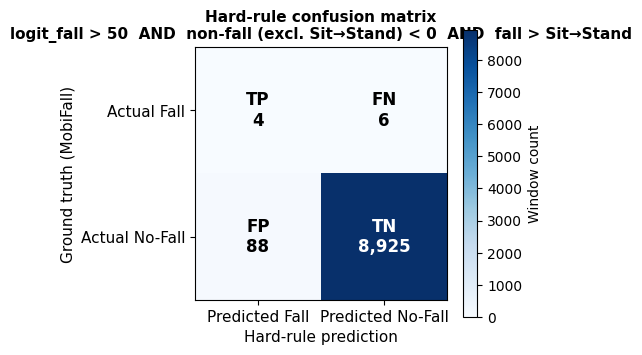

--- Fall recall per fall type ---
  FOL (Forward-lying       ):   1/  1 = 1.000
  FKL (Front-knees-lying   ):   1/  2 = 0.500
  BSC (Back-sitting-chair  ):   2/  7 = 0.286
  SDL (Sideward-lying      ):   0/  0 = 0.000

=== Comparison: softmax argmax vs Stand→Sit exempt vs Sit→Stand exempt ===
                                    Sens      Spec      TP      FP      FN
----------------------------------------------------------------------
Softmax argmax                    0.8000    0.1006       8   8,106       2
Hard rule (Stand→Sit exempt)      0.0000    0.9994       0       5      10
Hard rule (Sit→Stand exempt)      0.4000    0.9902       4      88       6


In [63]:
CHU_IDX = CLASS_LIST.index(9)   # Sit→Stand (exempt from the < 0 requirement)

# All non-fall columns except Sit→Stand
NONFAL_EXCEPT_CHU = [i for i in range(len(CLASS_LIST))
                     if i != FALL_CLS_IDX and i != CHU_IDX]


def apply_hard_rule_chu(logits_arr):
    """
    Fall  <=>  logit_fall > FALL_LOGIT_THRESH
               AND  max(non-fall logits except Sit→Stand) < 0
               AND  logit_fall > logit_Sit→Stand
    """
    logit_fall = logits_arr[:, FALL_CLS_IDX]
    logit_chu  = logits_arr[:, CHU_IDX]
    max_other  = logits_arr[:, NONFAL_EXCEPT_CHU].max(axis=1)
    return (logit_fall > FALL_LOGIT_THRESH) & (max_other < 0) & (logit_fall > logit_chu)


# ── Apply rule ────────────────────────────────────────────────────────────
hard_fall_chu = apply_hard_rule_chu(all_logits)

tp_c, fn_c, fp_c, tn_c, sens_c, spec_c, f1_c = _eval_rule(
    hard_fall_chu, is_gt_fall,
    f'logit_fall > {FALL_LOGIT_THRESH}  AND  non-fall (excl. Sit→Stand) < 0  AND  fall > Sit→Stand'
)

# ── Per fall-type recall ───────────────────────────────────────────────────
print('--- Fall recall per fall type ---')
fall_arr_c = hard_fall_chu[:len(fall_labels_gt)]
for code in FALL_CODES:
    mask       = np.array(fall_source_codes) == code
    preds_code = fall_arr_c[mask]
    recall_c   = preds_code.mean() if len(preds_code) > 0 else 0.0
    print(f'  {code} ({FALL_DESCRIPTIONS[code]:20s}): '
          f'{preds_code.sum():3d}/{len(preds_code):3d} = {recall_c:.3f}')

# ── Three-way comparison ───────────────────────────────────────────────────
print()
print('=== Comparison: softmax argmax vs Stand→Sit exempt vs Sit→Stand exempt ===')
print(f'{"":30s}  {"Sens":>8}  {"Spec":>8}  {"TP":>6}  {"FP":>6}  {"FN":>6}')
print('-' * 70)
print(f'{"Softmax argmax":30s}  {soft_sens:>8.4f}  {soft_spec:>8.4f}  '
      f'{soft_tp:>6,}  {soft_fp:>6,}  {soft_fn:>6,}')
print(f'{"Hard rule (Stand→Sit exempt)":30s}  {sensitivity:>8.4f}  {specificity:>8.4f}  '
      f'{tp:>6,}  {fp:>6,}  {fn:>6,}')
print(f'{"Hard rule (Sit→Stand exempt)":30s}  {sens_c:>8.4f}  {spec_c:>8.4f}  '
      f'{tp_c:>6,}  {fp_c:>6,}  {fn_c:>6,}')

## 14. Window Visualisation — TP / FN / FP (Sit→Stand-exempt rule)

Each window shows the **normalised 3-axis accelerometer signal** (top) and the **Fall & Sit→Stand logit values** (bottom).  
Border colour: green = True Positive · orange = False Negative · red = False Positive.  
Gold dashed line = fall-logit threshold (50); grey dotted line = logit 0.

TP=4  FN=6  FP total=88  (showing 8 FP)



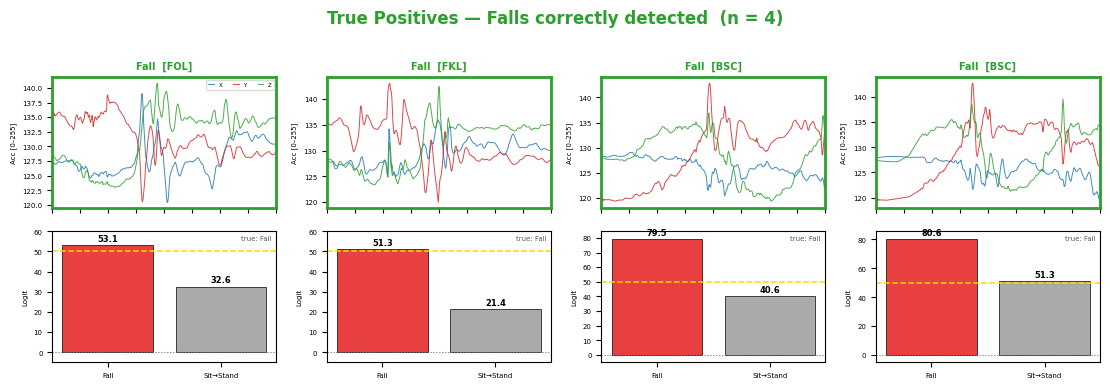

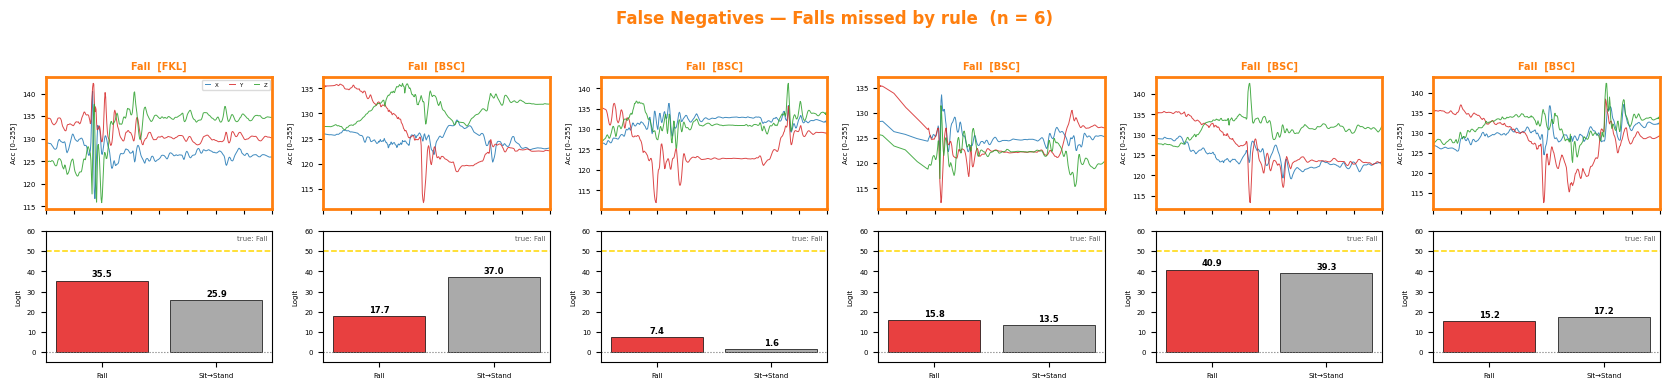

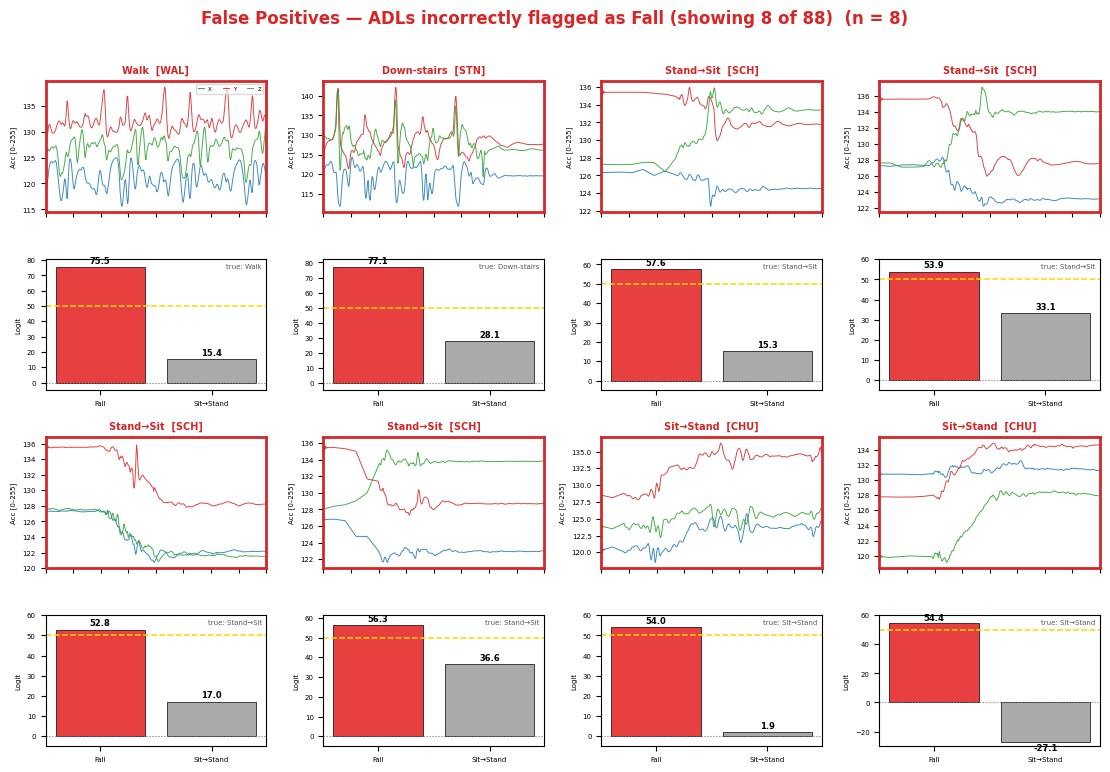

In [64]:
N_FP_SHOW = 8   # max FP windows to display (randomly sampled)

# ── Window classification under the Sit→Stand-exempt rule ─────────────────
tp_idx = np.where( hard_fall_chu &  is_gt_fall)[0]
fn_idx = np.where(~hard_fall_chu &  is_gt_fall)[0]
fp_idx = np.where( hard_fall_chu & ~is_gt_fall)[0]

rng_vis = np.random.default_rng(42)
fp_show = np.sort(rng_vis.choice(fp_idx, size=min(N_FP_SHOW, len(fp_idx)), replace=False))

# Source-code label for every window (falls first, then ADLs)
src_codes = np.array(fall_source_codes + adl_source_codes, dtype=object)

t_win      = np.arange(WIN_LEN) / float(FS_CNN)   # 0 … 4 s
AXES_CLR   = ['#1f77b4', '#d62728', '#2ca02c']     # X / Y / Z
AXES_NAMES = ['X', 'Y', 'Z']


def _plot_group(indices, group_label, border_color, n_cols=6):
    """One figure per group: 2 matplotlib rows per window (signal + logit bars)."""
    if len(indices) == 0:
        print(f'  No {group_label} windows.')
        return

    n_wins  = len(indices)
    ncols   = min(n_cols, n_wins)
    nrows_g = int(np.ceil(n_wins / ncols))   # logical rows of windows

    fig, axes = plt.subplots(
        nrows_g * 2, ncols,
        figsize=(ncols * 2.8, nrows_g * 3.8),
        squeeze=False,
    )
    fig.suptitle(f'{group_label}  (n = {n_wins})',
                 fontsize=12, fontweight='bold', color=border_color, y=1.01)

    for k, idx in enumerate(indices):
        r_s = (k // ncols) * 2     # signal row index
        r_l = r_s + 1               # logit row index
        c   = k % ncols

        ax_s = axes[r_s, c]
        ax_l = axes[r_l, c]

        # ── Accelerometer signal ──────────────────────────────────────────
        sig = all_windows[idx].reshape(WIN_LEN, 3)   # (400, 3) normalised [0–255]
        for a in range(3):
            ax_s.plot(t_win, sig[:, a], color=AXES_CLR[a], lw=0.7,
                      alpha=0.85, label=AXES_NAMES[a])

        ax_s.set_xlim(0, WIN_LEN / FS_CNN)
        ax_s.tick_params(labelsize=5, labelbottom=False)
        ax_s.set_ylabel('Acc [0–255]', fontsize=5)
        for sp in ax_s.spines.values():
            sp.set_edgecolor(border_color)
            sp.set_linewidth(2.0)

        gt_cls = int(all_gt[idx])
        src    = src_codes[idx]
        ax_s.set_title(f'{CLASS_NAMES[gt_cls]}  [{src}]',
                       fontsize=7, fontweight='bold', color=border_color)
        if k == 0:
            ax_s.legend(fontsize=4, loc='upper right', ncol=3,
                        handlelength=1, framealpha=0.7)

        # ── Fall & Sit→Stand logit bars ───────────────────────────────────
        l_fall = float(all_logits[idx, FALL_CLS_IDX])
        l_chu  = float(all_logits[idx, CHU_IDX])

        bar_vals   = [l_fall, l_chu]
        bar_labels = ['Fall', 'Sit→Stand']
        bar_colors = [CLASS_COLORS[0], CLASS_COLORS[9]]

        bars = ax_l.bar(bar_labels, bar_vals, color=bar_colors,
                        edgecolor='black', linewidth=0.5)
        ax_l.axhline(FALL_LOGIT_THRESH, color='gold', ls='--', lw=1.1)
        ax_l.axhline(0, color='0.45', ls=':', lw=0.8)

        # Value labels on bars
        for xi, val in enumerate(bar_vals):
            va  = 'bottom' if val >= 0 else 'top'
            off = 1.0 if val >= 0 else -1.0
            ax_l.text(xi, val + off, f'{val:.1f}',
                      ha='center', va=va, fontsize=6, fontweight='bold')

        # Y range: always show the threshold and zero
        y_lo = min(-5.0, l_fall - 3, l_chu - 3)
        y_hi = max(FALL_LOGIT_THRESH + 10, l_fall + 5, l_chu + 5)
        ax_l.set_ylim(y_lo, y_hi)
        ax_l.tick_params(labelsize=5)
        ax_l.set_ylabel('Logit', fontsize=5)

        # True-label badge in logit panel
        ax_l.text(0.98, 0.97, f'true: {CLASS_NAMES[gt_cls]}',
                  transform=ax_l.transAxes, fontsize=5,
                  ha='right', va='top', color='0.35')

    # Hide unused axes cells
    for k in range(n_wins, nrows_g * ncols):
        r_s = (k // ncols) * 2
        axes[r_s,     k % ncols].axis('off')
        axes[r_s + 1, k % ncols].axis('off')

    plt.tight_layout()
    plt.show()


print(f'TP={len(tp_idx)}  FN={len(fn_idx)}  FP total={len(fp_idx)}  '
      f'(showing {len(fp_show)} FP)')
print()

_plot_group(tp_idx,  'True Positives — Falls correctly detected',       '#2ca02c', n_cols=6)
_plot_group(fn_idx,  'False Negatives — Falls missed by rule',          '#ff7f0e', n_cols=6)
_plot_group(fp_show,
            f'False Positives — ADLs incorrectly flagged as Fall '
            f'(showing {len(fp_show)} of {len(fp_idx)})',
            '#d62728', n_cols=min(4, len(fp_show)))

In [59]:
sess.close()
print('TF session closed.')

TF session closed.
